# Mura dataset Visualization

In [ ]:
# mount it
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import csv
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
# #Unzip dataset
!unzip /content/drive/MyDrive/Extra_work/MURA-v1.1.zip -d /content/drive/MyDrive/Extra_work/MURA

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/train/XR_FOREARM/patient09674/study1_negative/image1.png  
   creating: /content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/train/XR_FOREARM/patient07761/
   creating: /content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/train/XR_FOREARM/patient07761/study1_negative/
  inflating: /content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/train/XR_FOREARM/patient07761/study1_negative/image2.png  
  inflating: /content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/train/XR_FOREARM/patient07761/study1_negative/image1.png  
   creating: /content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/train/XR_FOREARM/patient07761/study2_negative/
  inflating: /content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/train/XR_FOREARM/patient07761/study2_negative/image1.png  
  inflating: /content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/train/XR_FOREARM/patient07761/study2_negative/image2.png  
   creating: /content/drive/MyDri

In [ ]:
train_df = pd.read_csv('/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/train_image_paths.csv', header=None, names=['path'])
valid_df = pd.read_csv('/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/valid_image_paths.csv', header=None, names=['path'])

In [ ]:
train_df.head(3)

,path
0,MURA-v1.1/train/XR_SHOULDER/patient00001/study...
1,MURA-v1.1/train/XR_SHOULDER/patient00001/study...
2,MURA-v1.1/train/XR_SHOULDER/patient00001/study...


In [ ]:
valid_df.head(3)

,path
0,MURA-v1.1/valid/XR_WRIST/patient11185/study1_p...
1,MURA-v1.1/valid/XR_WRIST/patient11185/study1_p...
2,MURA-v1.1/valid/XR_WRIST/patient11185/study1_p...


In [ ]:
# Define a function to extract the class labels from the image path
def extract_class(path):
    return path.split("/")[-4] + "_" + path.split("/")[-2].split("_")[-1].upper()

train_df['class'] = train_df['path'].apply(extract_class)
valid_df['class'] = valid_df['path'].apply(extract_class)

In [ ]:
train_df.tail(3)

,path,class
36805,MURA-v1.1/train/XR_HAND/patient11184/study1_ne...,XR_HAND_NEGATIVE
36806,MURA-v1.1/train/XR_HAND/patient11184/study1_ne...,XR_HAND_NEGATIVE
36807,MURA-v1.1/train/XR_HAND/patient11184/study1_ne...,XR_HAND_NEGATIVE


In [ ]:
valid_df.head(3)

,path,class
0,MURA-v1.1/valid/XR_WRIST/patient11185/study1_p...,XR_WRIST_POSITIVE
1,MURA-v1.1/valid/XR_WRIST/patient11185/study1_p...,XR_WRIST_POSITIVE
2,MURA-v1.1/valid/XR_WRIST/patient11185/study1_p...,XR_WRIST_POSITIVE


In [ ]:
new_classes = valid_df[['class']].drop_duplicates()
class_labels = [i for i in new_classes['class']]

print("\nTotal Classes are",len(new_classes), "\n New classes are", class_labels)


Total Classes are 14 
 New classes are ['XR_WRIST_POSITIVE', 'XR_WRIST_NEGATIVE', 'XR_FOREARM_POSITIVE', 'XR_FOREARM_NEGATIVE', 'XR_HAND_POSITIVE', 'XR_HAND_NEGATIVE', 'XR_HUMERUS_POSITIVE', 'XR_HUMERUS_NEGATIVE', 'XR_SHOULDER_POSITIVE', 'XR_SHOULDER_NEGATIVE', 'XR_ELBOW_POSITIVE', 'XR_ELBOW_NEGATIVE', 'XR_FINGER_POSITIVE', 'XR_FINGER_NEGATIVE']


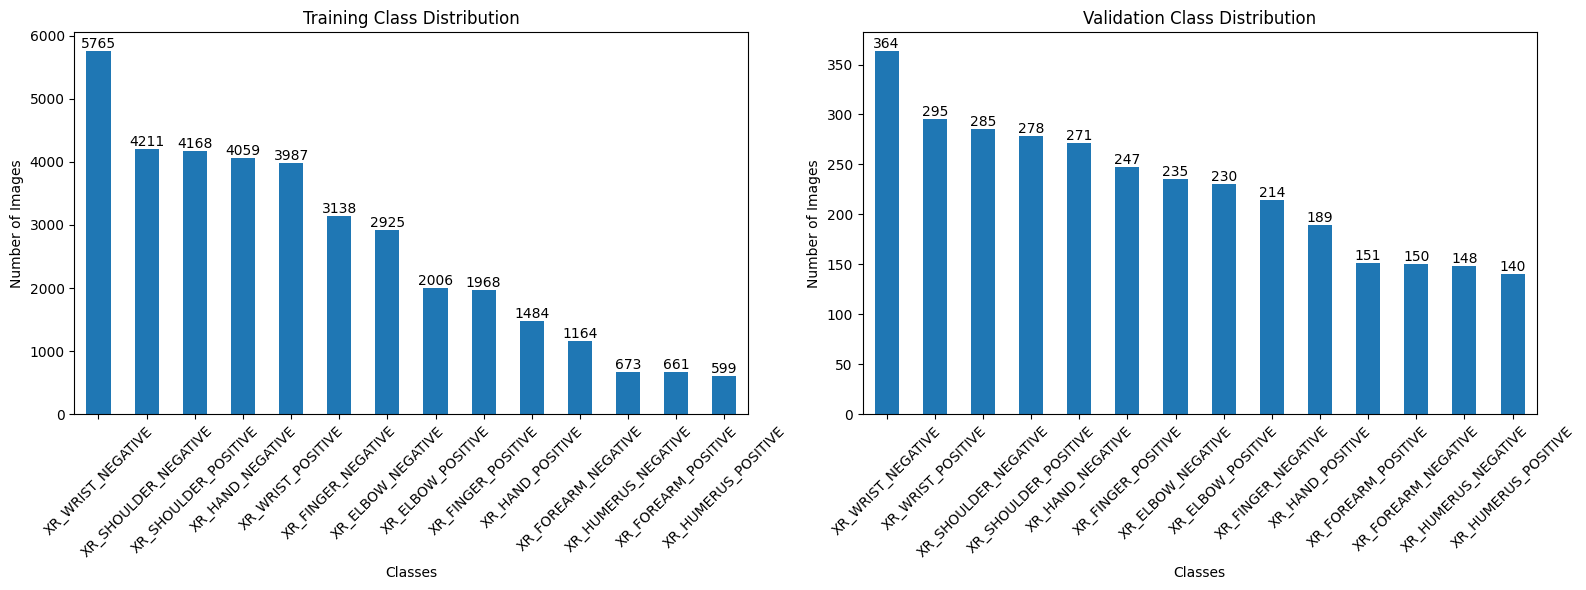

In [ ]:
# Count the number of images in each class for the training & Validation dataset
train_class_counts = train_df['class'].value_counts()
valid_class_counts = valid_df['class'].value_counts()


# Create a new figure with two subplots (1 row, 2 columns)
plt.figure(figsize=(16, 6))

# Subplot for the training dataset
plt.subplot(1, 2, 1)
train_class_counts.plot(kind='bar')
plt.title('Training Class Distribution')
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
for i, v in enumerate(train_class_counts):
    plt.text(i, v, str(v), ha='center', va='bottom')

# Subplot for the validation dataset
plt.subplot(1, 2, 2)
valid_class_counts.plot(kind='bar')
plt.title('Validation Class Distribution')
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
for i, v in enumerate(valid_class_counts):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

FileNotFoundError: ignored

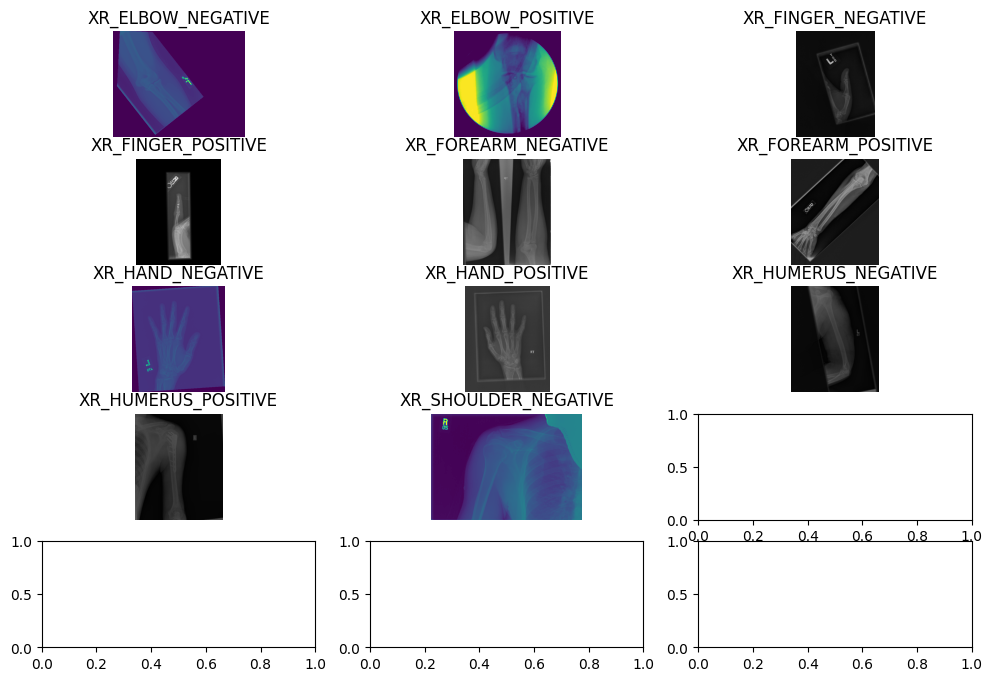

In [ ]:
#Display Images of Each class
class_groups = train_df.groupby('class')['path'].apply(list)

# Create a subplot grid based on the number of classes
num_classes = len(class_groups)
cols = 3
rows = (num_classes + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(12, 8))

for i, (class_name, paths) in enumerate(class_groups.items()):
    random_path = "/content/drive/MyDrive/Extra_work/MURA/" + paths[0]

    image = Image.open(os.path.join(random_path))

    row = i // cols
    col = i % cols

    ax = axes[row, col]
    ax.imshow(image)
    ax.set_title(class_name)
    ax.axis('off')

if num_classes % cols != 0:
    for i in range(num_classes, rows * cols):
        fig.delaxes(axes.flatten()[i])

plt.tight_layout()
plt.show()

# Create Sigle Dataset csv
merge bith csv files

In [ ]:
#concatinate both csv files
mura_df = pd.concat([train_df, valid_df], axis=0)

#save as total dataset csv files
mura_df.to_csv('/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/mura_dataset.csv', index=False)

prev_train_count = len(train_df['path'])
pre_valid_count = len(valid_df['path'])
total_images = len(mura_df['class'])

print("Total Images in Dataset is",total_images)

In [ ]:
# Count the number of images in each class
mura_class_counts = mura_df['class'].value_counts()

# Create a bar chart to visualize the class distribution
plt.figure(figsize=(12, 6))
ax = mura_class_counts.plot(kind='bar')
plt.title('MURA Dataset Class Distribution')
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)

# Add exact counts as text labels on top of each bar
for i, v in enumerate(mura_class_counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.show()

### Check Positive Negtive classes Distribution

In [ ]:
temp_mura_df = mura_df
#extract positive or Negtive class
def extract_class(class_name):
    return class_name.split("_")[-1]

temp_mura_df['label'] = temp_mura_df['class'].apply(extract_class)

temp_mura_df.head(3)

,path,class,label
0,MURA-v1.1/train/XR_SHOULDER/patient00001/study...,XR_SHOULDER_POSITIVE,POSITIVE
1,MURA-v1.1/train/XR_SHOULDER/patient00001/study...,XR_SHOULDER_POSITIVE,POSITIVE
2,MURA-v1.1/train/XR_SHOULDER/patient00001/study...,XR_SHOULDER_POSITIVE,POSITIVE


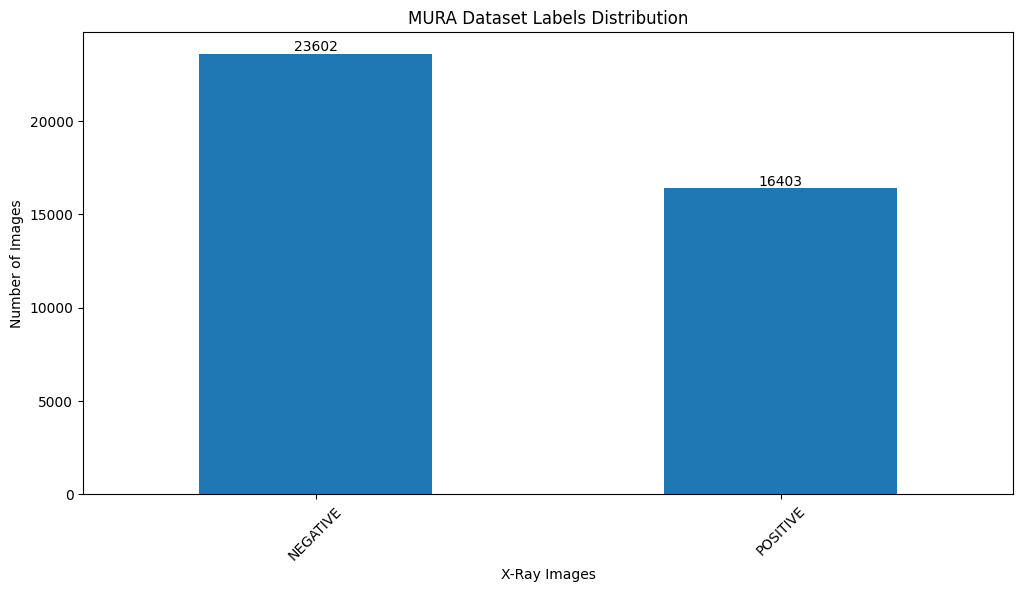

In [ ]:
# Count the number of images in each class
mura_label_counts = temp_mura_df['label'].value_counts()

# Create a bar chart to visualize the class distribution
plt.figure(figsize=(12, 6))
ax = mura_label_counts.plot(kind='bar')
plt.title('MURA Dataset Labels Distribution')
plt.xlabel('X-Ray Images')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)

# Add exact counts as text labels on top of each bar
for i, v in enumerate(mura_label_counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.show()

## Create csv file for each class

In [ ]:
mura_df
# List of unique classes
unique_classes = mura_df['class'].unique()
classes_df = []

# Create a separate CSV file for each class
for class_name in unique_classes:
    class_df = mura_df[mura_df['class'] == class_name]

    output_file_name = f"{class_name}.csv".lower()

    class_df.to_csv("/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/" + output_file_name, index=False)

    print(f"Saved {output_file_name}")

print("All CSV files created.")

Saved xr_shoulder_positive.csv
Saved xr_shoulder_negative.csv
Saved xr_humerus_positive.csv
Saved xr_humerus_negative.csv
Saved xr_finger_positive.csv
Saved xr_finger_negative.csv
Saved xr_elbow_positive.csv
Saved xr_elbow_negative.csv
Saved xr_wrist_positive.csv
Saved xr_wrist_negative.csv
Saved xr_forearm_positive.csv
Saved xr_forearm_negative.csv
Saved xr_hand_positive.csv
Saved xr_hand_negative.csv
All CSV files created.


In [ ]:
classes_df = []
df = pd.read_csv("/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/train_image_paths.csv")
classes_df.append(df)
df = pd.read_csv("/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/valid_labeled_studies.csv")
classes_df.append(df)
# def find_new_df(folder_path):
#     csv_files = []
#     for root, dirs, files in os.walk(folder_path):
#       if "/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/{train|calid}/" in root:
#         continue
#         #print("-->",root)
#         # for file in files:
#         #     if file.endswith('.csv') and file.startswith("xr_"):
#         #         temp = file.split("_")
#         #         new_df_name = temp[1] + "_" + temp[2][0]
#         #         print(new_df_name)
#         #         #csv_files.append(os.path.join(root, file))
#         #         # path = os.path.join(root, file)
#         #         # temp_pd = pd.read_csv(path)

#         #         # final_df = pd.concat([temp_dict[temp_pd['class'][0]],temp_pd],axis=0)
#         #         # file_name = f"final_{temp_pd['class'][0]}.csv".lower()
#         #         # final_df.to_csv(f"/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/{file_name}", index=False)
#         #         # print(f"\n\t{temp_pd['class'][0]} = ",len(file_df[temp_pd['class'][0]]))

# # Example usage:
# folder_path = "/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1"
# find_new_df(folder_path)
classes_df[1].head(3)

,MURA-v1.1/valid/XR_WRIST/patient11185/study1_positive/,1
0,MURA-v1.1/valid/XR_WRIST/patient11186/study1_p...,1
1,MURA-v1.1/valid/XR_WRIST/patient11186/study2_p...,1
2,MURA-v1.1/valid/XR_WRIST/patient11186/study3_p...,1


In [ ]:
shoulder_p = pd.read_csv("/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/xr_shoulder_positive.csv")
shoulder_n = pd.read_csv("/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/xr_shoulder_negative.csv")
humerus_p = pd.read_csv("/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/xr_humerus_positive.csv")
humerus_n = pd.read_csv("/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/xr_humerus_negative.csv")
finger_p = pd.read_csv("/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/xr_finger_positive.csv")
finger_n = pd.read_csv("/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/xr_finger_negative.csv")
elbow_p = pd.read_csv("/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/xr_elbow_positive.csv")
elbow_n = pd.read_csv("/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/xr_elbow_negative.csv")
wrist_p = pd.read_csv("/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/xr_wrist_positive.csv")
wrist_n = pd.read_csv("/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/xr_wrist_negative.csv")
forearm_p = pd.read_csv("/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/xr_forearm_positive.csv")
forearm_n = pd.read_csv("/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/xr_forearm_negative.csv")
hand_p = pd.read_csv("/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/xr_hand_positive.csv")
hand_n = pd.read_csv("/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/xr_hand_negative.csv")

print("xr_shoulder_positive has",len(shoulder_p['path']),"images.")
print("xr_shoulder_negative has",len(shoulder_n['path']),"images.")
print("xr_humerus_positive has",len(humerus_p['path']),"images.")
print("xr_humerus_negative has",len(humerus_n['path']),"images.")
print("xr_finger_positive has",len(finger_p['path']),"images.")
print("xr_finger_negative has",len(finger_n['path']),"images.")
print("xr_elbow_positive has",len(elbow_p['path']),"images.")
print("xr_elbow_negative has",len(elbow_n['path']),"images.")
print("xr_wrist_positive has",len(wrist_p['path']),"images.")
print("xr_wrist_negative has",len(wrist_n['path']),"images.")
print("xr_forearm_positive has",len(forearm_p['path']),"images.")
print("xr_forearm_negative has",len(forearm_n['path']),"images.")
print("xr_hand_positive has",len(hand_p['path']),"images.")
print("xr_hand_negative has",len(hand_n['path']),"images.")

xr_shoulder_positive has 4446 images.
xr_shoulder_negative has 4496 images.
xr_humerus_positive has 739 images.
xr_humerus_negative has 821 images.
xr_finger_positive has 2215 images.
xr_finger_negative has 3352 images.
xr_elbow_positive has 2236 images.
xr_elbow_negative has 3160 images.
xr_wrist_positive has 4282 images.
xr_wrist_negative has 6129 images.
xr_forearm_positive has 812 images.
xr_forearm_negative has 1314 images.
xr_hand_positive has 1673 images.
xr_hand_negative has 4330 images.


## Data Augumentation

In [ ]:
def augment_images(img_df, desired_images_count, target_size=(256, 256)):

    #check required length
    if len(img_df['path']) < desired_images_count:

      new_rows = []
      augmented_csv_path = ""
      count = 1
      for i in tqdm(range(desired_images_count - len(img_df['path']) + 1)):

        #select random image
        try:
          idx = random.randint(1, (len(img_df['path'])-1))
          random_val = img_df.iloc[idx]
        except:
          print(idx,"Index out of range")
          break

        split_val = random_val['class'].replace(random_val['label'],"")[:-1]

        image_path = f"/content/drive/MyDrive/Extra_work/MURA/" + random_val['path']
        output_dir = image_path.split(split_val)[0] + f"{split_val}/augumented_data_{random_val['class'].lower()}/"
        output_dir = output_dir.replace("valid","train")

        os.makedirs(output_dir, exist_ok=True)
        augmented_csv_path = output_dir + f"augument_{random_val['class'].lower()}.csv"

        image = cv2.imread(image_path)

        if image is None:
          continue

        rotation_angle = random.randint(1, 180)

        if random.choice([True, False]):
            image = np.fliplr(image)
        if random.choice([True, False]):
            image = np.flipud(image)

        height, width, _ = image.shape
        min_dim = min(height, width)
        if min_dim < 125:
            continue

        # Rotate the image
        M = cv2.getRotationMatrix2D((width / 2, height / 2), rotation_angle, 1)
        image = cv2.warpAffine(image, M, (width, height))

        # Resize the image
        image = cv2.resize(image, target_size)

        # Save the augmented image
        base_name = f"aug_{count}_" + os.path.basename(image_path)
        count = count + 1
        output_path = os.path.join(output_dir, base_name)
        cv2.imwrite(output_path, image)

        op_path = random_val['path'].split(split_val)[0] + f"{split_val}" + output_path.split(split_val)[-1]
        op_path = op_path.replace("valid","train")
        new_rows.append({'path': op_path , 'class' : random_val['class'], 'label': random_val['label']})


      # Create a new DataFrame with augmented data
      augmented_df = pd.DataFrame(new_rows)
      augmented_df.to_csv(augmented_csv_path, index=False)
      print("\n\n\t -->",count,"new Images are genrated")

In [ ]:
augment_images(humerus_p,6200)
augment_images(humerus_n,6200)
augment_images(shoulder_p,6200)
augment_images(shoulder_n,6200)
augment_images(finger_p,6200)
augment_images(finger_n,6200)
augment_images(elbow_p,6200)
augment_images(elbow_n,6200)
augment_images(wrist_p,6200)
augment_images(wrist_n,6200)
augment_images(forearm_p,6200)
augment_images(forearm_n,6200)
augment_images(hand_p,6200)
augment_images(hand_n,6200)

100%|██████████| 5462/5462 [02:16<00:00, 40.07it/s]




	 --> 5463 new Images are genrated


In [ ]:
temp_dict = {"XR_FOREARM_POSITIVE" : forearm_p, "XR_FOREARM_NEGATIVE" : forearm_n,
        "XR_HAND_POSITIVE" : hand_p, "XR_HAND_NEGATIVE" : hand_n,
        "XR_FINGER_POSITIVE" : finger_p, "XR_FINGER_NEGATIVE" : finger_n,
        "XR_WRIST_POSITIVE" : wrist_p, "XR_WRIST_NEGATIVE" : wrist_n,
        "XR_HUMERUS_POSITIVE" : humerus_p, "XR_HUMERUS_NEGATIVE" : humerus_p,
        "XR_ELBOW_POSITIVE" : elbow_p, "XR_ELBOW_NEGATIVE" : elbow_n,
        "XR_SHOULDER_POSITIVE" : shoulder_p, "XR_SHOULDER_NEGATIVE" : shoulder_n}

print("After Augumentation images count")
def find_csv_files_in_folder(folder_path):
    csv_files = []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.endswith('.csv'):
                #csv_files.append(os.path.join(root, file))
                path = os.path.join(root, file)
                temp_pd = pd.read_csv(path)

                final_df = pd.concat([temp_dict[temp_pd['class'][0]],temp_pd],axis=0)
                file_name = f"final_{temp_pd['class'][0]}.csv".lower()
                final_df.to_csv(f"/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/{file_name}", index=False)
                print(f"\n\t{temp_pd['class'][0]} = ",len(file_df[temp_pd['class'][0]]))

# Example usage:
folder_path = "/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/train"
find_csv_files_in_folder(folder_path)

After Augumentation images count


KeyboardInterrupt: ignored

In [ ]:
dfs_to_concatenate = []

for df in final_dict.values():
    dfs_to_concatenate.append(df)

final_mura_df = pd.concat(dfs_to_concatenate, ignore_index=True)

print("\nAfter augumentation total images are",len(final_mura_df))
final_mura_df.to_csv(f"/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/final_mura.csv", index=False)
final_mura_df.head(3)


After augumentation tota images are 86654


,path,class,label
0,MURA-v1.1/train/XR_FOREARM/patient09083/study1...,XR_FOREARM_POSITIVE,POSITIVE
1,MURA-v1.1/train/XR_FOREARM/patient09083/study1...,XR_FOREARM_POSITIVE,POSITIVE
2,MURA-v1.1/train/XR_FOREARM/patient05601/study1...,XR_FOREARM_POSITIVE,POSITIVE


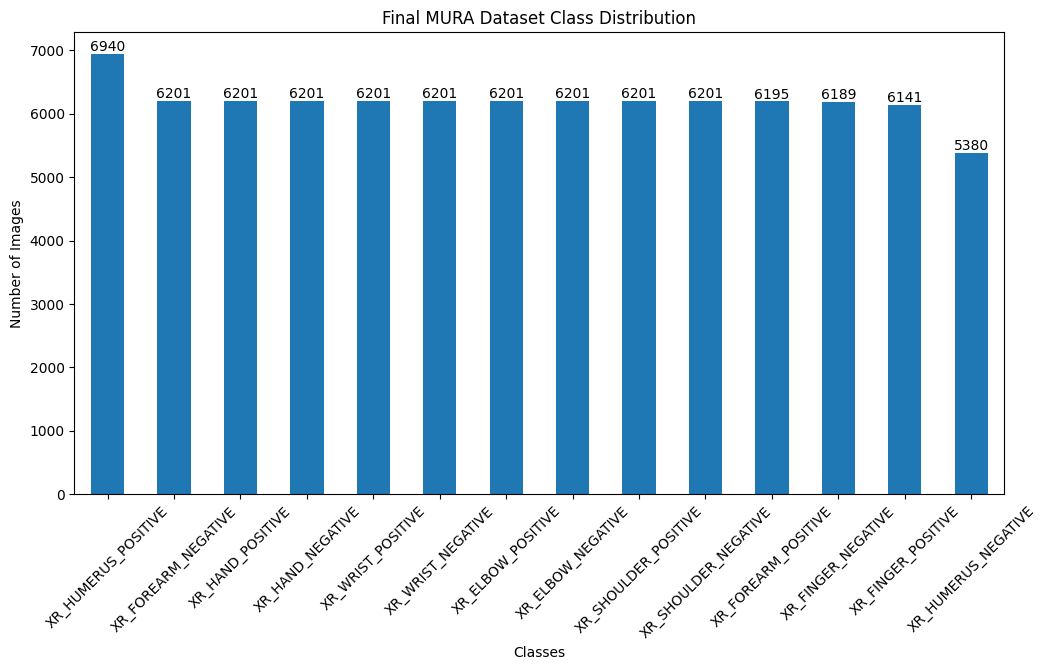

In [ ]:
# Count the number of images in each class
final_mura_class_counts = final_mura_df['class'].value_counts()

# Create a bar chart to visualize the class distribution
plt.figure(figsize=(12, 6))
ax = final_mura_class_counts.plot(kind='bar')
plt.title('Final MURA Dataset Class Distribution')
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)

# Add exact counts as text labels on top of each bar
for i, v in enumerate(final_mura_class_counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.show()